In [1]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np
import pandas as pd

In [2]:
df = pd.read_csv(r"C:\Users\nandi\Documents\ML_CO2_ER\data\df_merged.csv")

In [3]:
df.head()

,solvent_ID,smiles,Binding_Energy_eV,solubility_CO2 [mol/L],viscosity [Pa s],nAcid,nBase,SpAbs_A,SpMax_A,SpDiam_A,...,lumo_eV,homo_lumo_gap_eV,polarizability_ang3,min_partial_charge,max_partial_charge,min_abs_partial_charge,max_abs_partial_charge,vib_freq_min_cm1,vib_freq_max_cm1,vib_freq_count
0,zinc_5593217,COCCNC(=O)[C@@H](CC)C,-0.246414,0.097848,0.011764,0.0,0.0,12.906117,2.122425,4.244850,...,-6.330932,181.930993,748.130500,-0.832151,0.392923,0.034817,0.832151,23.0414,3627.7857,78.0
1,zinc_400210175,CO[C@H](C1CC1)CN1CCCCC1,-0.239933,0.117575,0.007448,0.0,1.0,17.343700,2.348592,4.557405,...,1.910386,161.701629,933.997796,-1.140739,0.562172,0.001836,1.140739,28.8558,3225.7980,96.0
2,zinc_5696920,NOCCN(C)C,-0.219656,0.097619,0.002281,0.0,1.0,7.727407,1.931852,3.863703,...,4.894440,168.343554,496.654099,-0.802413,0.379028,0.149089,0.802413,52.1440,3517.7383,51.0
3,zinc_685002938,C[C@@H](CN(CC1CC1)CC(F)F)O,-0.325154,0.088216,0.025603,0.0,1.0,14.943352,2.294945,4.451333,...,-1.984432,171.357226,807.127445,-0.794729,0.647513,0.076133,0.794729,26.9357,3729.3970,84.0
4,zinc_52602135,CNC[C@@H](C(C)C)OC,-0.288984,0.131763,0.001110,0.0,1.0,10.199109,2.119166,4.238332,...,2.317639,167.803019,655.958528,-0.847175,0.397601,0.172656,0.847175,62.5690,3522.0361,72.0


### Remove other 2 predictors when training.

In [4]:
meta_cols = ['solvent_ID', 'smiles']
# target = 'Binding_Energy_eV'  # or 'solubility_CO2 [mol/L]', 'viscosity [Pa s]'
target = 'solubility_CO2 [mol/L]'  # or 'solubility_CO2 [mol/L]', 'viscosity [Pa s]'
X = df.drop(columns=meta_cols + [target, 'viscosity [Pa s]', 'Binding_Energy_eV'])
y = df[target]

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

<Axes: xlabel='solubility_CO2 [mol/L]', ylabel='Count'>

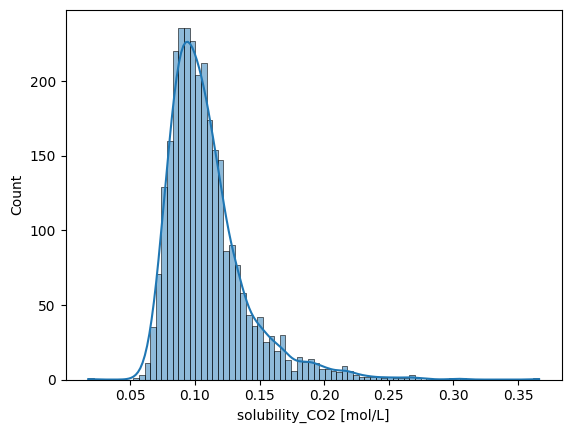

In [6]:
sns.histplot(y, kde=True)

In [7]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [8]:
from sklearn.preprocessing import PowerTransformer

pt = PowerTransformer(method='yeo-johnson')  # works with negatives too
y_train_trans = pt.fit_transform(y_train.values.reshape(-1, 1)).flatten()

In [9]:
# from sklearn.preprocessing import QuantileTransformer
# qt = QuantileTransformer(output_distribution='normal')
# y_train_trans = qt.fit_transform(y_train.values.reshape(-1, 1)).flatten()

<Axes: ylabel='Count'>

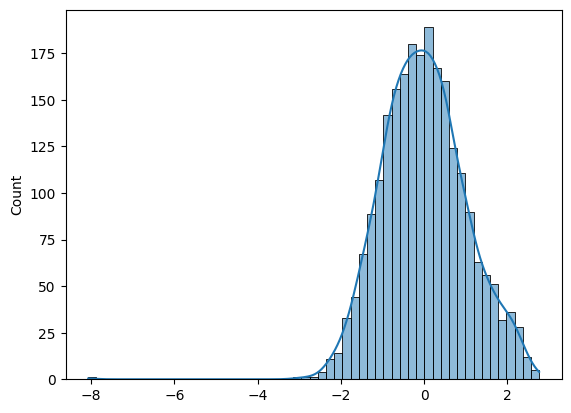

In [10]:
sns.histplot(y_train_trans, kde=True)

In [11]:
from sklearn.preprocessing import StandardScaler

In [12]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [16]:
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score


scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import RandomizedSearchCV

# Initialize RF Regressor
rf = RandomForestRegressor(random_state=42, n_jobs=-1)

# Define RF-specific hyperparameter space
param_dist = {
    'n_estimators': [100, 200, 300, 500],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': [None, 'sqrt', 'log2']
}

# Randomized search
random_search = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_dist,
    n_iter=30,
    scoring='neg_mean_squared_error',
    cv=10,
    verbose=1,
    n_jobs=4  # RF supports parallel processing
)

# Train the model
random_search.fit(X_train_scaled, y_train_trans)



Fitting 10 folds for each of 30 candidates, totalling 300 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestR...ndom_state=42)
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'max_depth': [None, 10, ...], 'max_features': [None, 'sqrt', ...], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 5, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",30
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'neg_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",4
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies 

In [17]:
random_search.best_estimator_

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",500
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",30
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",4
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples

In [18]:
best_params = random_search.best_params_
final_model = RandomForestRegressor(
    **best_params,
    random_state=42
)

In [20]:
final_model.fit(
    X_train_scaled,
    y_train_trans
)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",500
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",30
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",4
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples

Fixed RMSE: 0.0091
Fixed R²: 0.9061
Fixed RMSE (Train): 0.0072
Fixed R² (Train): 0.9463


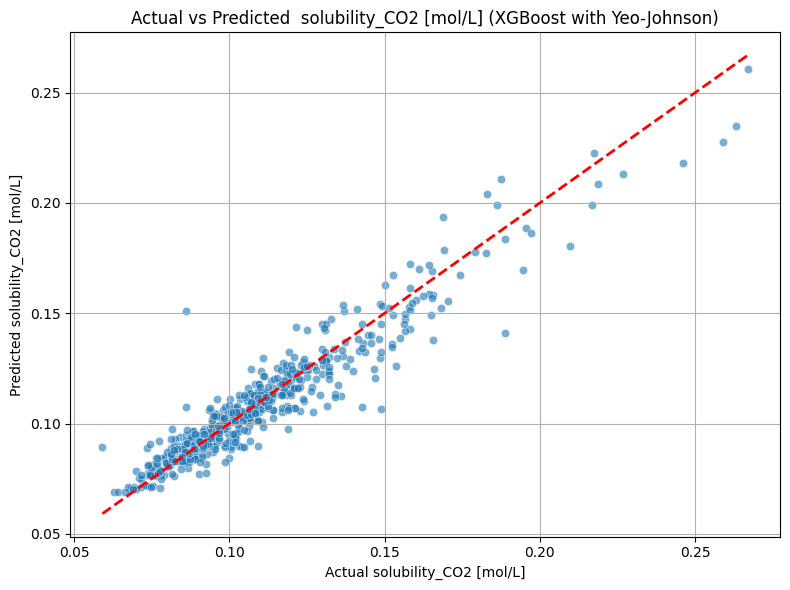

In [21]:
y_pred_trans = final_model.predict(X_test_scaled)
y_pred_train_trans = final_model.predict(X_train_scaled)
y_pred = pt.inverse_transform(y_pred_trans.reshape(-1, 1)).flatten()
y_pred_train = pt.inverse_transform(y_pred_train_trans.reshape(-1, 1)).flatten()
# y_pred = qt.inverse_transform(y_pred_trans.reshape(-1, 1)).flatten()
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
rmse_train = np.sqrt(mean_squared_error(y_train, y_pred_train))
r2 = r2_score(y_test, y_pred)
r2_train = r2_score(y_train, y_pred_train)

print("Fixed RMSE:", round(rmse, 4))
print("Fixed R²:", round(r2, 4))
print("Fixed RMSE (Train):", round(rmse_train, 4))
print("Fixed R² (Train):", round(r2_train, 4))

# -------------------------------------
# 6. Actual vs Predicted Plot
# -------------------------------------
plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', linewidth=2)
plt.xlabel("Actual solubility_CO2 [mol/L]")
plt.ylabel("Predicted solubility_CO2 [mol/L]")
plt.title("Actual vs Predicted  solubility_CO2 [mol/L] (XGBoost with Yeo-Johnson)")
plt.grid(True)
plt.tight_layout()
plt.show()

In [22]:
import shap

# Initialize SHAP explainer for tree models (GPU-safe)
# explainer = shap.Explainer(best_model)  # best_model = your trained XGBRegressor
explainer = shap.Explainer(final_model)  # best_model = your trained XGBRegressor

c:\Users\nandi\Documents\ML_CO2_ER\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [23]:
feature_names = X.columns.tolist()  # This should match the model's input

In [24]:
# Use scaled test set for SHAP input
import shap
explainer = shap.Explainer(final_model, feature_names=feature_names)
shap_values = explainer(X_test_scaled)

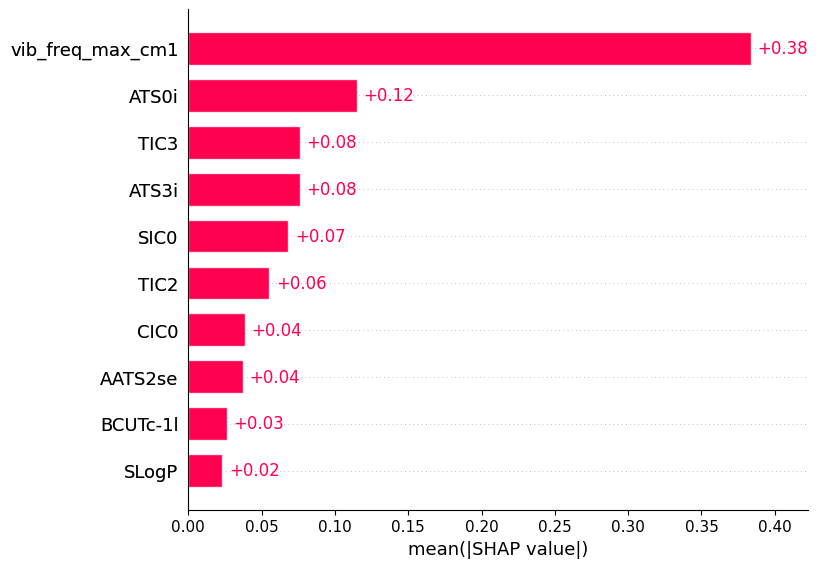

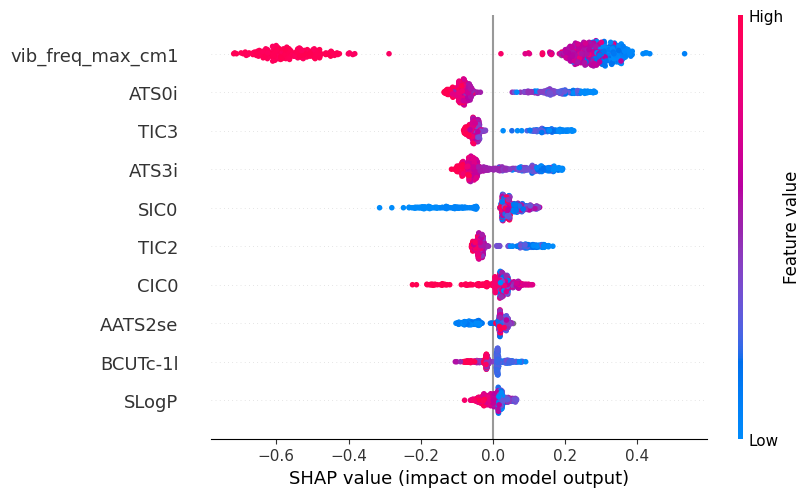

In [25]:
# Visualize top feature contributions across all samples
mean_shap = np.abs(shap_values.values).mean(axis=0)
top_10_indices = np.argsort(mean_shap)[-10:][::-1]

# Slice SHAP explanation to include only top 10 features
shap_values_top10 = shap.Explanation(
    values=shap_values.values[:, top_10_indices],
    base_values=shap_values.base_values,
    data=shap_values.data[:, top_10_indices],
    feature_names=np.array(shap_values.feature_names)[top_10_indices].tolist()
)

# Plot only top 10 features
shap.plots.bar(shap_values_top10)
shap.plots.beeswarm(shap_values_top10)


### Use actual descriptor names

### Check what descriptors we need to use

In [26]:
X_train.head(1)

,nAcid,nBase,SpAbs_A,SpMax_A,SpDiam_A,SpAD_A,SpMAD_A,LogEE_A,VE1_A,VE2_A,...,lumo_eV,homo_lumo_gap_eV,polarizability_ang3,min_partial_charge,max_partial_charge,min_abs_partial_charge,max_abs_partial_charge,vib_freq_min_cm1,vib_freq_max_cm1,vib_freq_count
252,0.0,1.0,13.354433,2.172565,4.34513,13.354433,1.112869,3.322301,2.918824,0.243235,...,-2.036265,176.35533,749.422107,-0.805377,0.781144,0.092901,0.805377,29.8689,3736.9532,81.0


### Predicted vs Actual values (include R2 score and rmse)
### Include a histogram of residuals

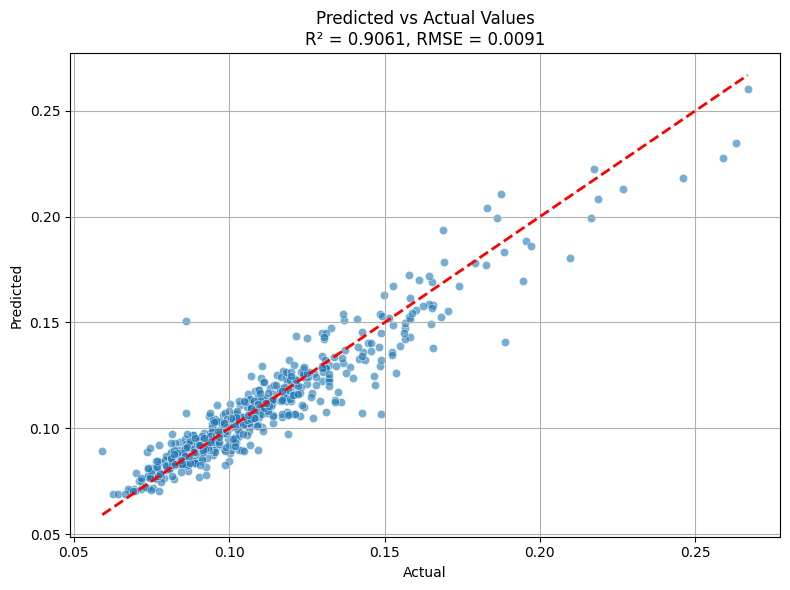

In [27]:
residuals = y_test - y_pred

# --- A. Predicted vs Actual Plot ---
plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()],
         'r--', linewidth=2)

plt.title(f"Predicted vs Actual Values\nR² = {r2:.4f}, RMSE = {rmse:.4f}")
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.grid(True)
plt.tight_layout()
plt.show()

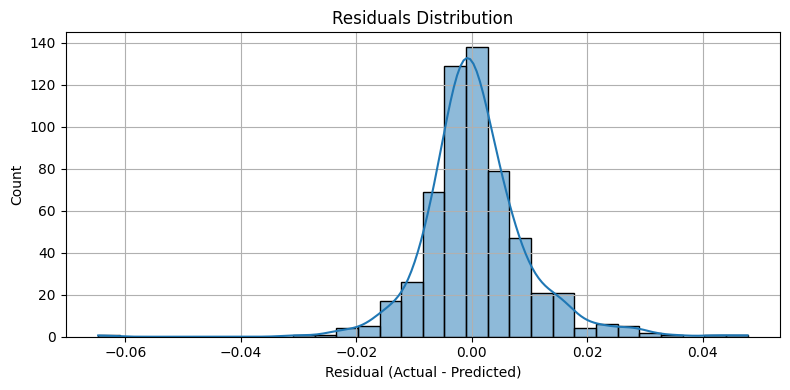

In [28]:
# --- B. Histogram of Residuals ---
plt.figure(figsize=(8, 4))
sns.histplot(residuals, kde=True, bins=30)
plt.title("Residuals Distribution")
plt.xlabel("Residual (Actual - Predicted)")
plt.ylabel("Count")
plt.grid(True)
plt.tight_layout()
plt.show()

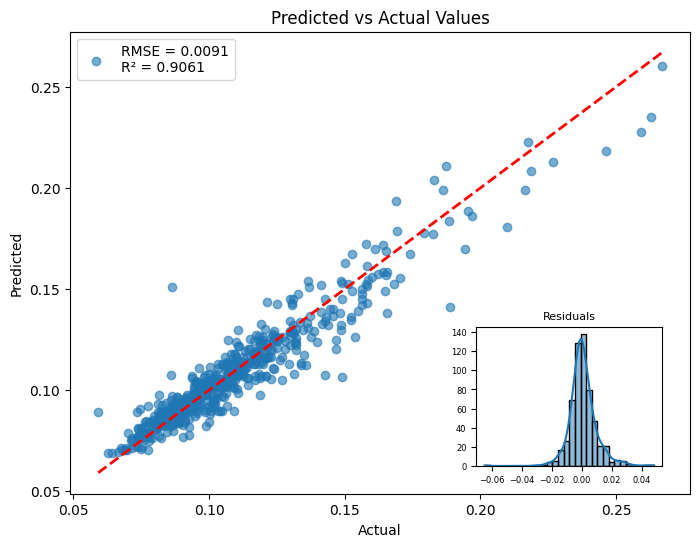

In [29]:
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(y_test, y_pred, alpha=0.6)
ax.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', linewidth=2)
ax.set_title("Predicted vs Actual Values")
ax.set_xlabel("Actual")
ax.set_ylabel("Predicted")
ax.legend([f'RMSE = {rmse:.4f}\nR² = {r2:.4f}'], loc='upper left')

# Inset Plot: Residuals Distribution
inset_ax = inset_axes(ax, width="30%", height="30%", loc='lower right', borderpad=2)
sns.histplot(residuals, bins=30, kde=True, ax=inset_ax)
inset_ax.set_title("Residuals", fontsize=8)
inset_ax.set_xlabel("")
inset_ax.set_ylabel("")
inset_ax.tick_params(labelsize=6)

C:\Users\nandi\AppData\Local\Temp\ipykernel_5596\1896114311.py:54: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


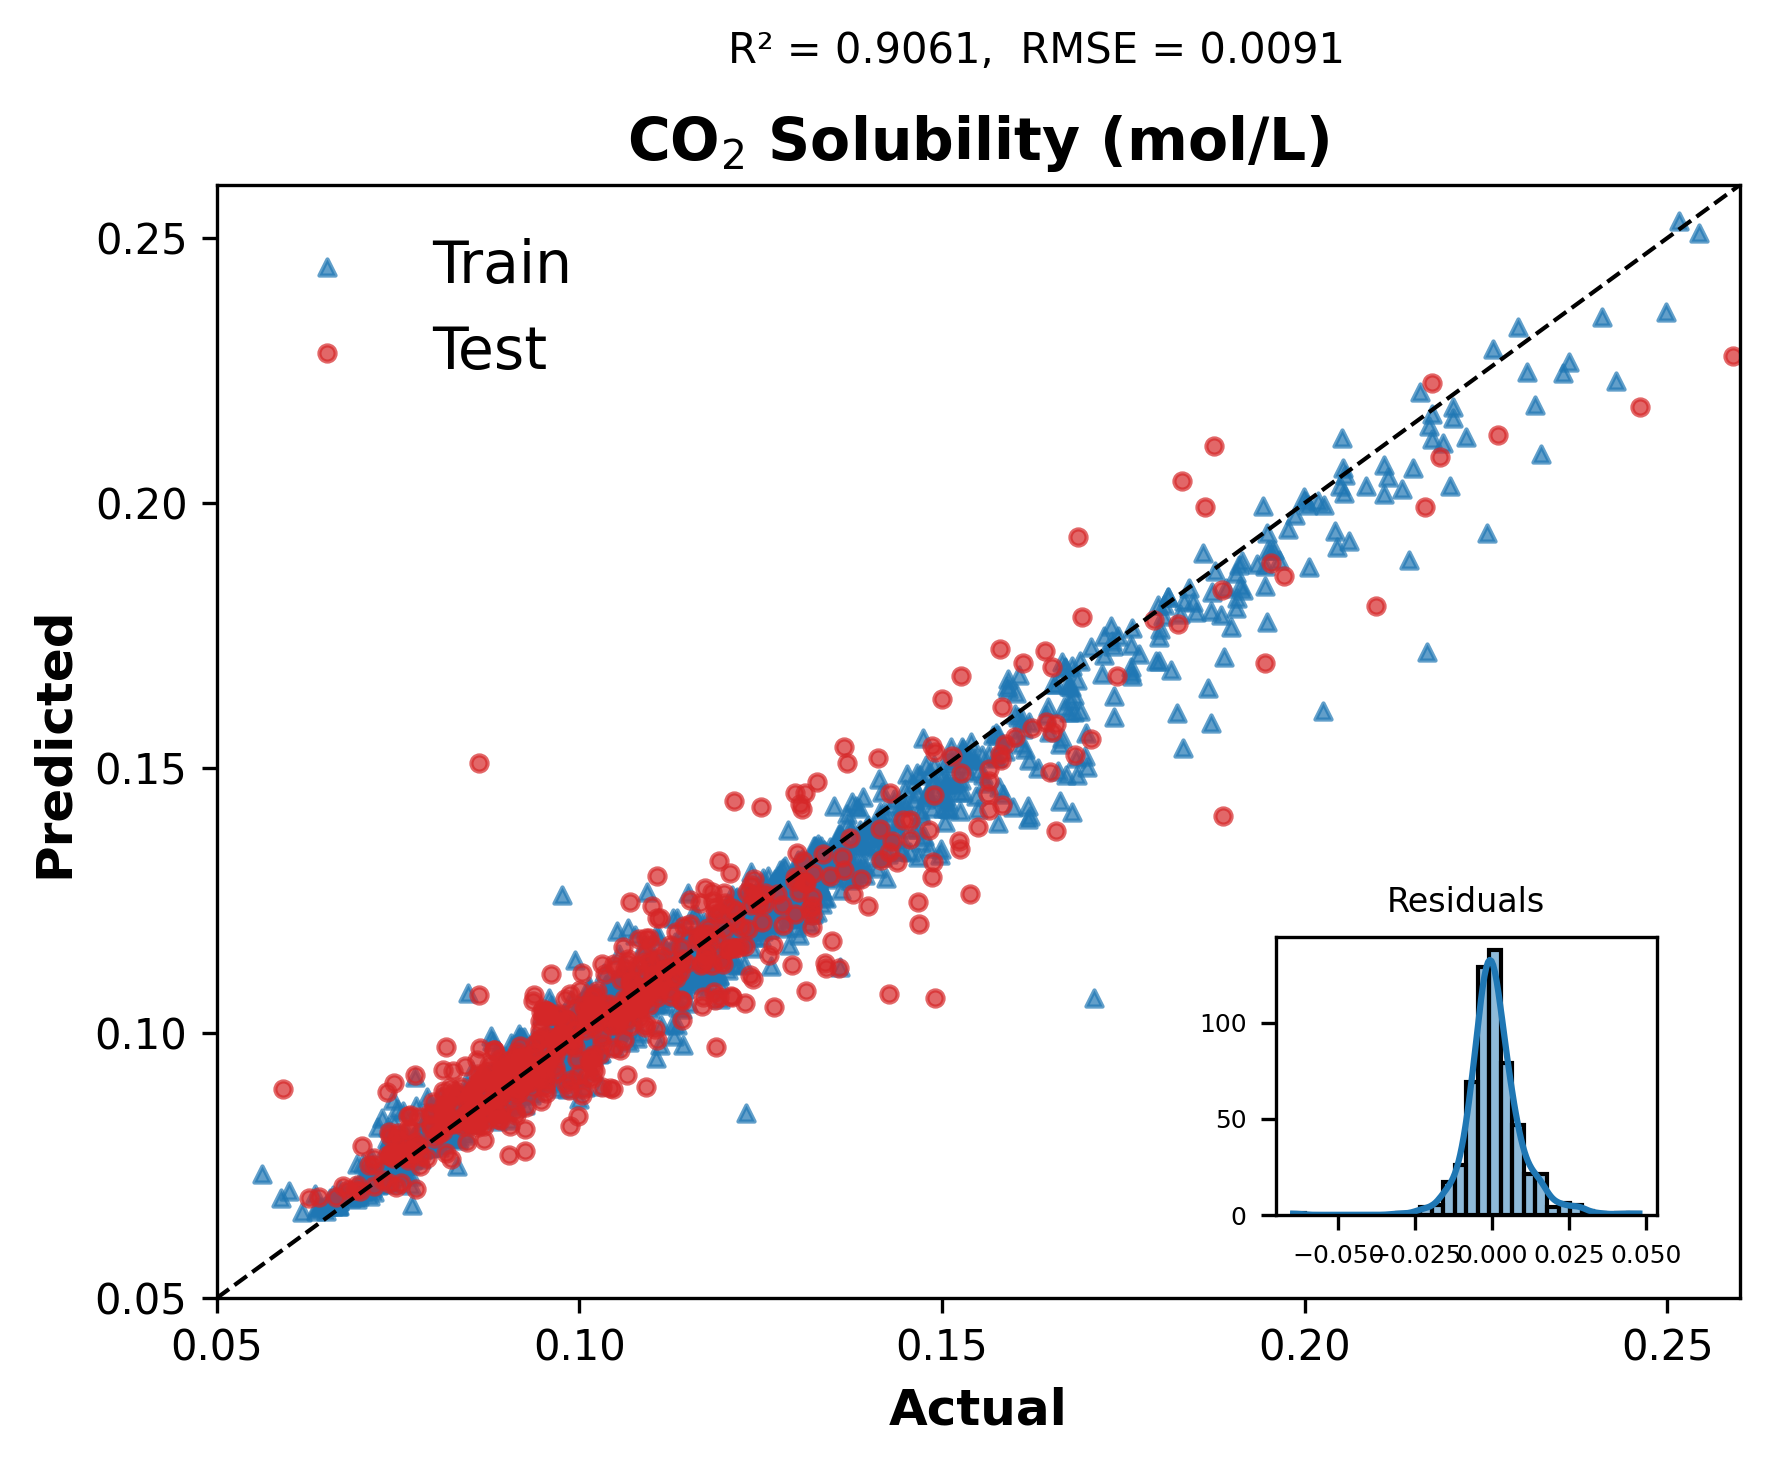

In [30]:
import matplotlib.pyplot as plt
import seaborn as sns
from mpl_toolkits.axes_grid1.inset_locator import inset_axes



# Invert the log transformation


fig, ax = plt.subplots(figsize=(6, 5), dpi=300)

# ➤ Scatter plots
ax.scatter(y_train, y_pred_train, alpha=0.7, s=15, color='tab:blue', marker='^', label='Train')
ax.scatter(y_test, y_pred, alpha=0.7, s=15, color='tab:red', marker='o', label='Test')

# ax.set_xticks([tick for tick in ax.get_yticks()])

# ax.set_xlim(0.05, right=5)
# ax.set_ylim(bottom=0.05, top=5)

ax.plot([0.05, y_test.max()], [0.05, y_test.max()], 'k--', linewidth=1)

ax.set_xlim(0.05, 0.26)
ax.set_ylim(0.05, 0.26)

# ➤ Main plot labels
ax.set_title("CO$_2$ Solubility (mol/L)", fontsize=14, fontweight='bold') # set 2 in CO2 as superscript
ax.set_xlabel("Actual", fontsize=12, fontweight='bold')
ax.set_ylabel("Predicted", fontsize=12, fontweight='bold')

ax.set_xticks([0.05, 0.10, 0.15, 0.20, 0.25])
ax.set_yticks([0.05, 0.10, 0.15, 0.20, 0.25])

ax.tick_params(axis='both', labelsize=10)

# ➤ R² and RMSE text
x_center = (y_test.min() + y_test.max()) / 2
y_top = y_pred.max() + (y_pred.max() - y_pred.min()) * 0.15
ax.text(x_center, y_top, f"R² = {r2:.4f},  RMSE = {rmse:.4f}",
        fontsize=10, ha='center', va='top')

# ➤ Legend
ax.legend(loc='upper left', fontsize=14, frameon=False)

# ➤ Inset plot for residuals
inset_ax = inset_axes(ax, width="25%", height="25%", loc='lower right', borderpad=2)
sns.histplot(residuals, bins=30, kde=True, ax=inset_ax)
inset_ax.set_title("Residuals", fontsize=8)
inset_ax.set_xlabel("")
inset_ax.set_ylabel("")
inset_ax.tick_params(labelsize=6)

# ➤ Save and display
plt.tight_layout()
plt.savefig("solvent_viscosity_fixed_TT.png", dpi=300, bbox_inches='tight')
plt.show()


C:\Users\nandi\AppData\Local\Temp\ipykernel_5596\1738561136.py:10: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "k--" (-> color='k'). The keyword argument will take precedence.
  ax.plot([0.05, y_test.max()], [0.05, y_test.max()], 'k--', linewidth=1, color='black')
C:\Users\nandi\AppData\Local\Temp\ipykernel_5596\1738561136.py:46: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


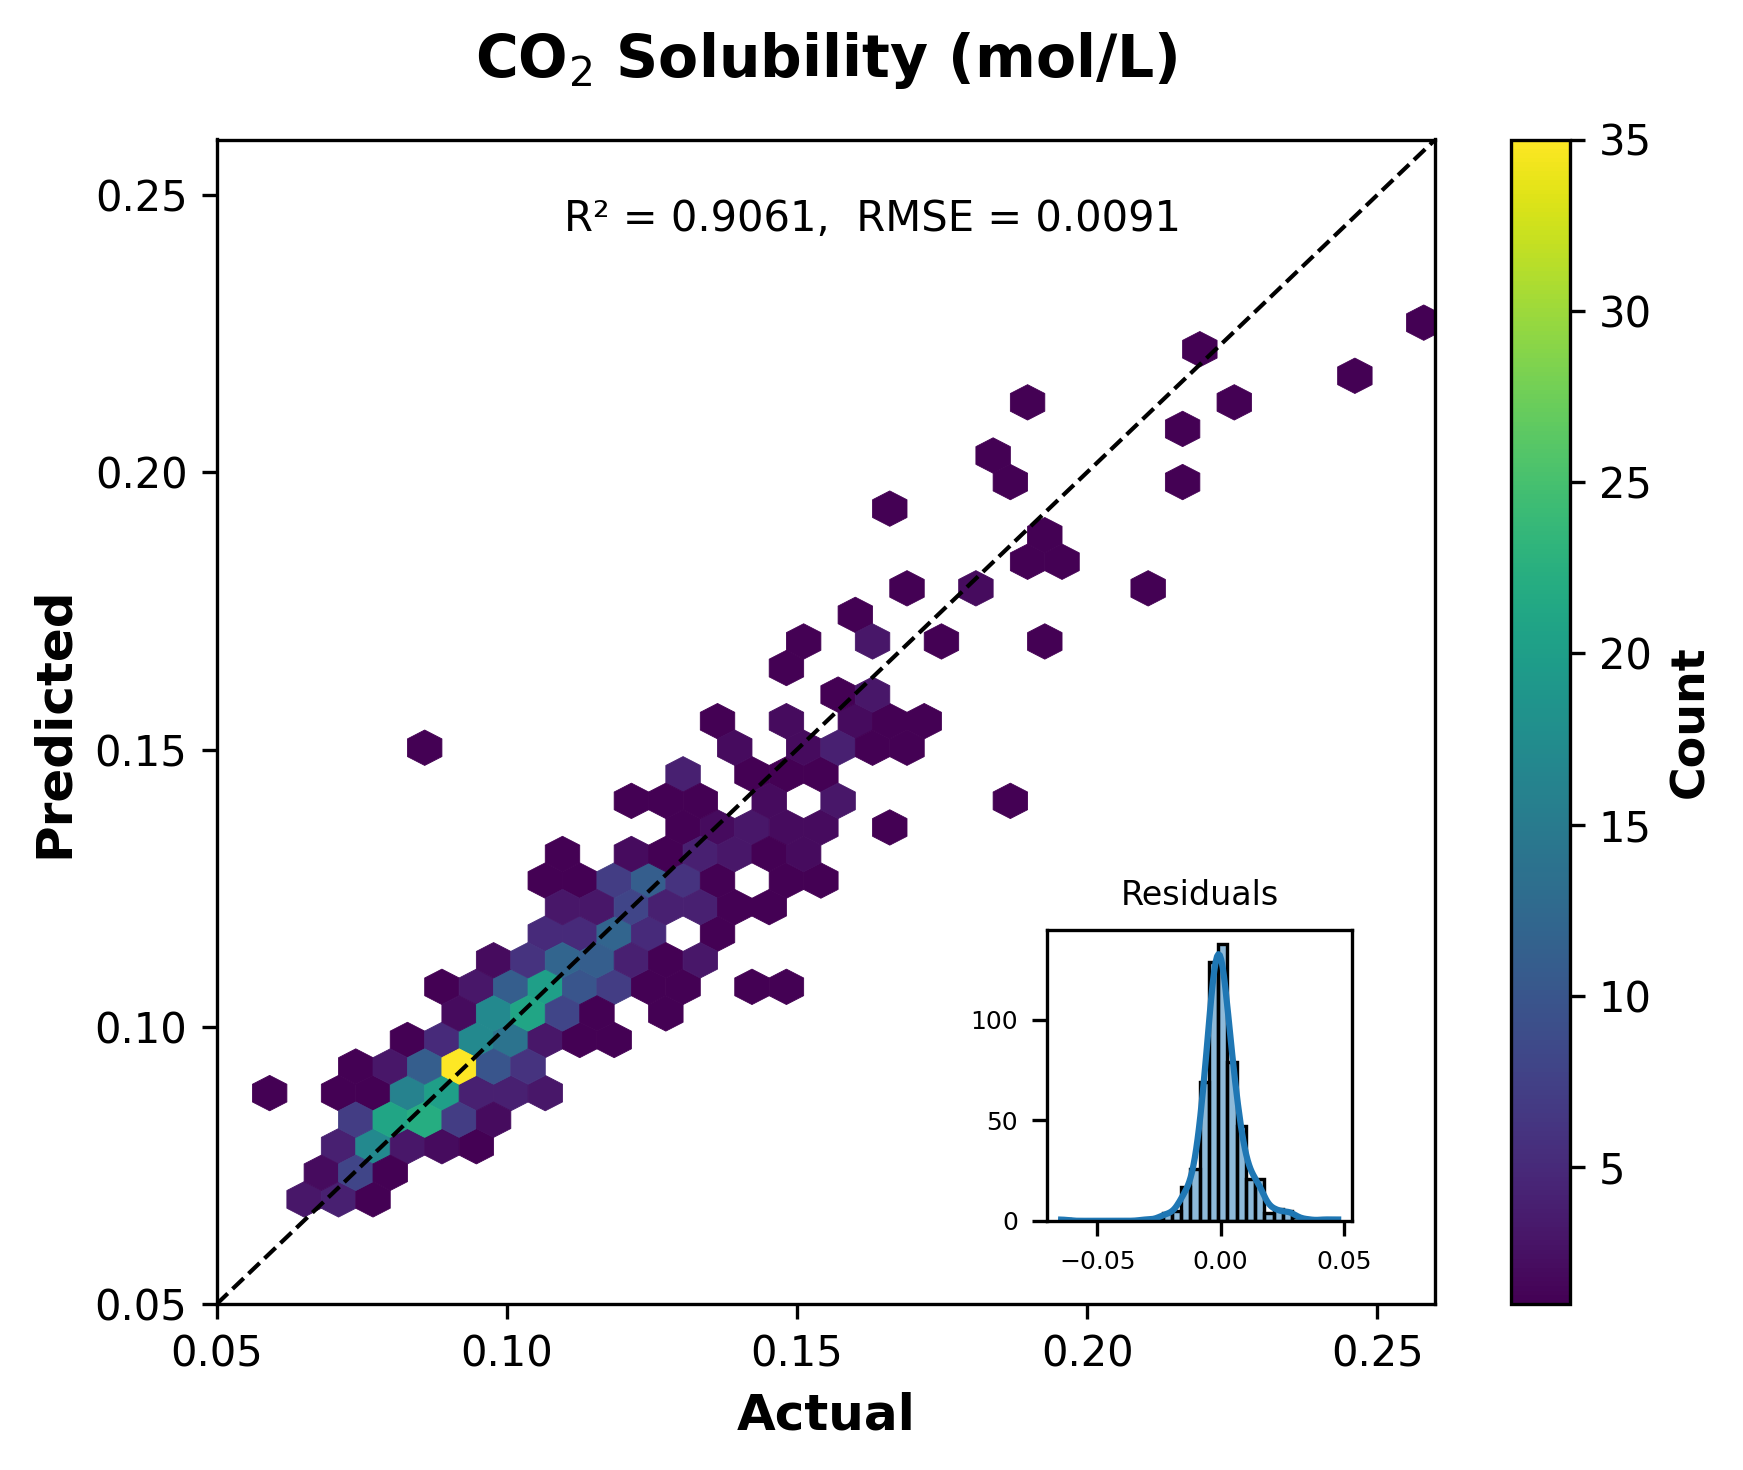

In [31]:
# Use point density plot (e.g. hexbin in matplotlib) instead of scatter plot for above to show the distribution information for the overlapped data points along with labeling the axes and adding a diagonal reference line.
fig, ax = plt.subplots(figsize=(6, 5), dpi=300)

# Create hexbin plot with better visibility
hb = ax.hexbin(y_test, y_pred, gridsize=35, cmap='viridis', mincnt=1, edgecolors='face', linewidths=0.2)
cb = plt.colorbar(hb, ax=ax)
cb.set_label('Count', fontsize=11, fontweight='bold')

# Diagonal reference line
ax.plot([0.05, y_test.max()], [0.05, y_test.max()], 'k--', linewidth=1, color='black')

# remove 0 tick mark from x and y axis
ax.set_xticks([0.05, 0.10, 0.15, 0.20, 0.25])
ax.set_yticks([0.05, 0.10, 0.15, 0.20, 0.25])

ax.set_xlim(0.05, 0.26)
ax.set_ylim(0.05, 0.26)

# adjust x and y axis range (max 5 - as original scatter plot)
# diagonal line -make sure it spans the whole plot range.
# ax.set_xlim(left=y_test.min(), right=y_test.max())
# ax.set_ylim(bottom=y_test.min(), top=y_test.max())



# Title and axes labels
ax.set_title(f"CO$_2$ Solubility (mol/L)", 
             fontsize=14, fontweight='bold', pad=15)
# this should be inside the plot
y_top = ax.get_ylim()[1] - 0.05 * (ax.get_ylim()[1] - ax.get_ylim()[0])
ax.text(x_center, y_top, f"R² = {r2:.4f},  RMSE = {rmse:.4f}",
        fontsize=10, ha='center', va='top')
ax.set_xlabel("Actual", fontsize=12, fontweight='bold')
ax.set_ylabel("Predicted", fontsize=12, fontweight='bold')
ax.tick_params(axis='both', labelsize=10)
# ➤ Inset residual plot
inset_ax = inset_axes(ax, width="25%", height="25%", loc='lower right', borderpad=2)
sns.histplot(residuals, bins=30, kde=True, ax=inset_ax)
inset_ax.set_title("Residuals", fontsize=8)
inset_ax.set_xlabel("")
inset_ax.set_ylabel("")
inset_ax.tick_params(labelsize=6)
# ax.legend(fontsize=11, loc='upper left')
# ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("Solubility_hexbin_density_plot_xgboost.png", dpi=300, bbox_inches='tight')
plt.show()

In [32]:
import joblib

# Save the Random Forest model
joblib.dump(final_model, 'rf_sol_model.pkl')

# Optionally, save the scaler as well for future predictions
joblib.dump(scaler, 'scaler_rf_sol_model.pkl')

print("Model and scaler saved successfully!")


Model and scaler saved successfully!


In [33]:
import pandas as pd
import numpy as np

# 1. Get feature importance from SHAP
# Sum the absolute SHAP values for each feature to find the top ones
feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': np.abs(shap_values.values).mean(axis=0)
}).sort_values(by='importance', ascending=False)

# 2. Select the top 6 features (adjust this number if you want a more precise equation)
top_features = feature_importance['feature'].head(10).tolist()

print(f"Top features for equation: {top_features}")

Top features for equation: ['vib_freq_max_cm1', 'ATS0i', 'TIC3', 'ATS3i', 'SIC0', 'TIC2', 'CIC0', 'AATS2se', 'BCUTc-1l', 'SLogP']


Linear Regression with Top 10 SHAP Features
RMSE: 0.0163
R²: 0.6998


C:\Users\nandi\AppData\Local\Temp\ipykernel_5596\941460794.py:23: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "k--" (-> color='k'). The keyword argument will take precedence.
  ax.plot([0.05, y_test.max()], [0.05, y_test.max()], 'k--', linewidth=1, color='black')
C:\Users\nandi\AppData\Local\Temp\ipykernel_5596\941460794.py:48: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


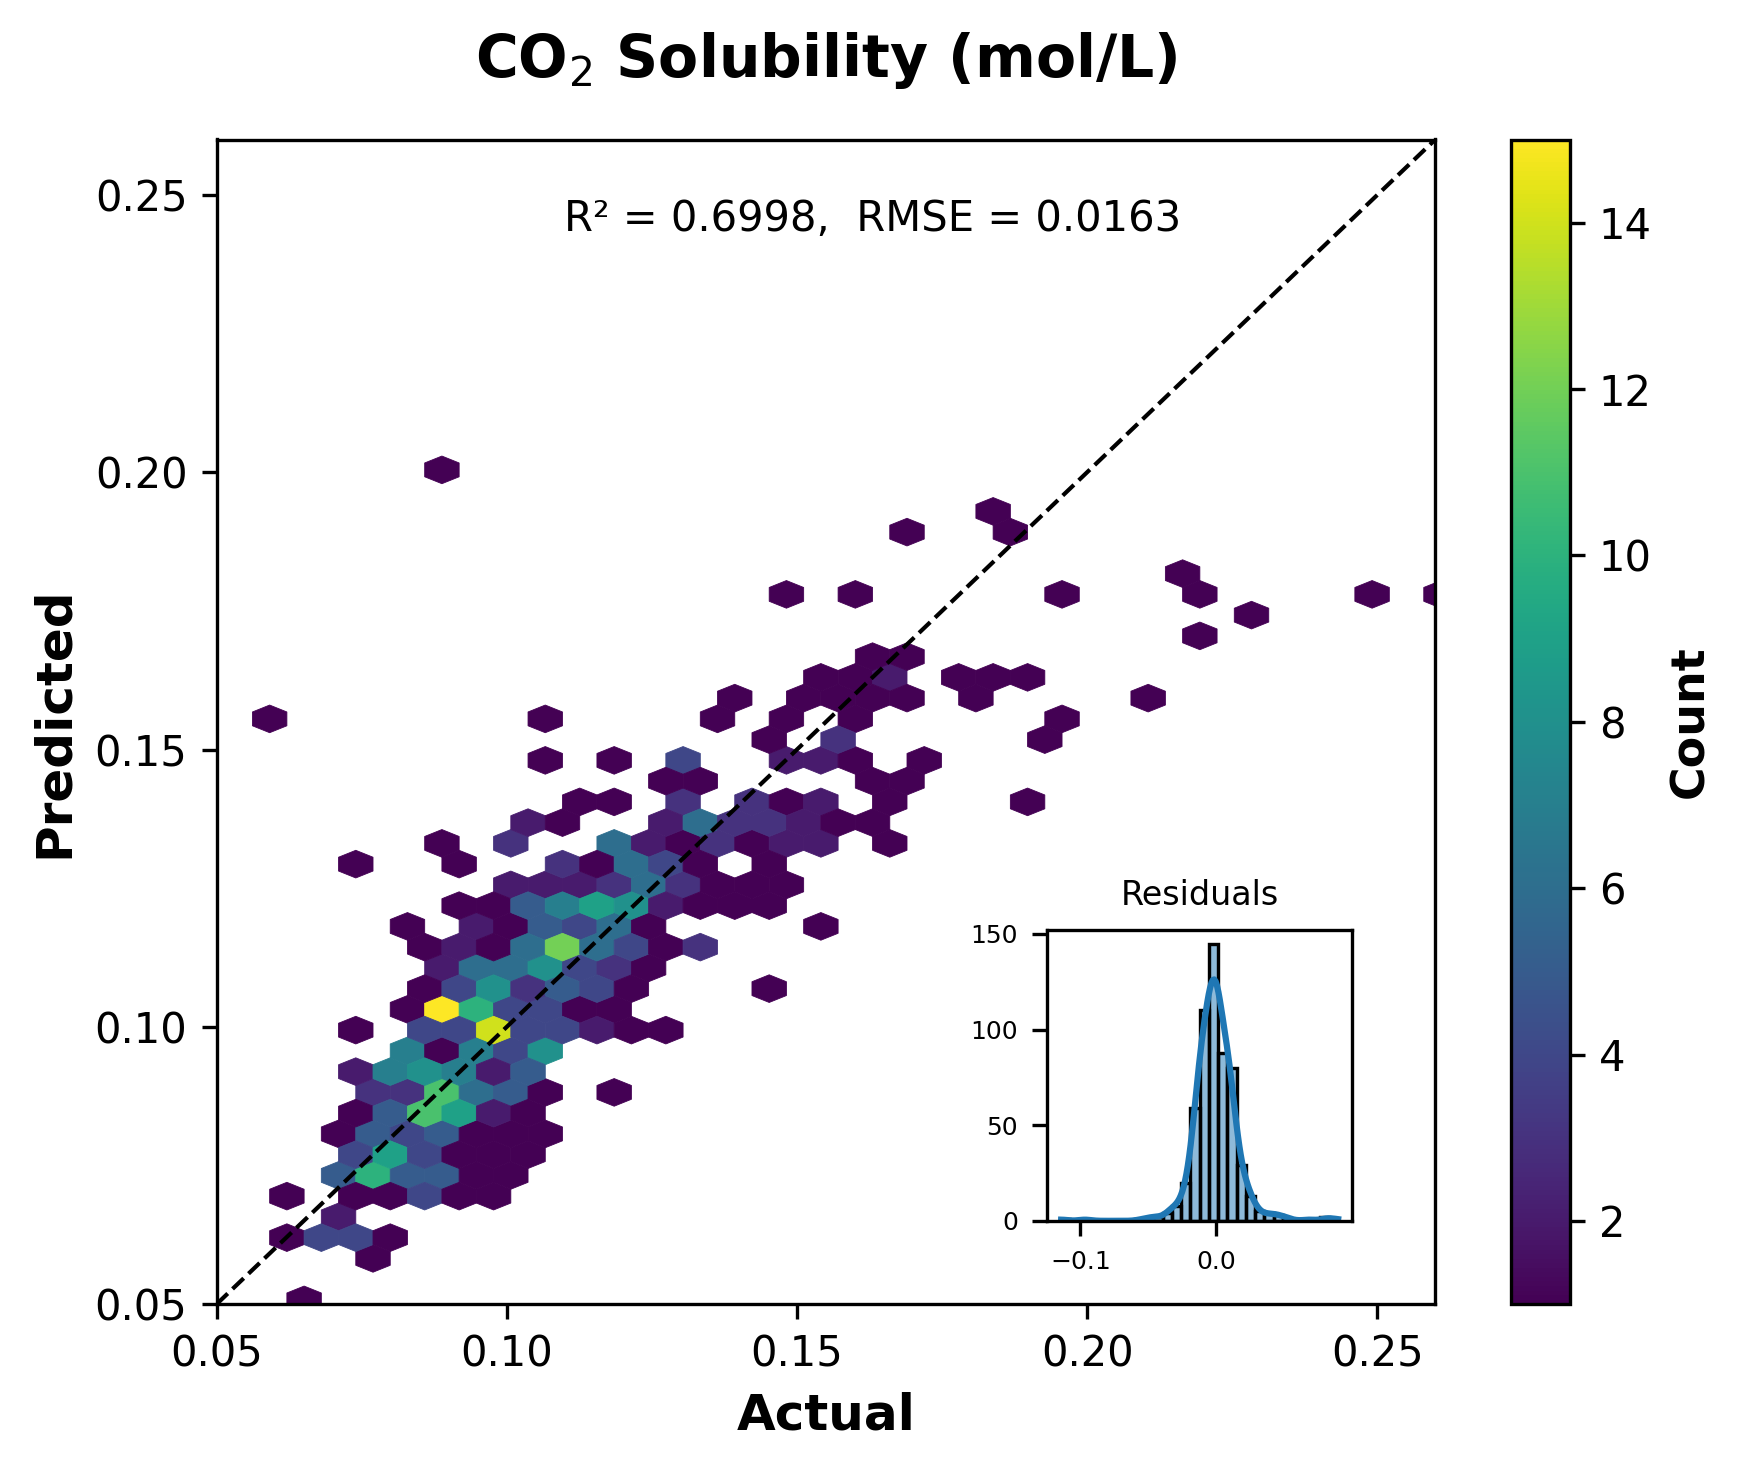

In [34]:
# Train a simple linear regression model using only the top 10 features from SHAP
from sklearn.linear_model import LinearRegression
X_train_top = X_train[top_features]
X_test_top = X_test[top_features]
lr_model = LinearRegression()

# Deal with NaN or inf values if any
X_train_top = X_train_top.replace([np.inf, -np.inf], np.nan).fillna(0)
X_test_top = X_test_top.replace([np.inf, -np.inf], np.nan).fillna(0)

lr_model.fit(X_train_top, y_train)
y_pred_top = lr_model.predict(X_test_top)
rmse_top = np.sqrt(mean_squared_error(y_test, y_pred_top))
r2_top = r2_score(y_test, y_pred_top)
print("Linear Regression with Top 10 SHAP Features")
print("RMSE:", round(rmse_top, 4))
print("R²:", round(r2_top, 4))
fig, ax = plt.subplots(figsize=(6, 5), dpi=300)
hb = ax.hexbin(y_test, y_pred_top, gridsize=35, cmap='viridis', mincnt=1, edgecolors='face', linewidths=0.2)
cb = plt.colorbar(hb, ax=ax)
cb.set_label('Count', fontsize=11, fontweight='bold')
# Diagonal reference line
ax.plot([0.05, y_test.max()], [0.05, y_test.max()], 'k--', linewidth=1, color='black')
# remove 0 tick mark from x and y axis
ax.set_xticks([0.05, 0.10, 0.15, 0.20, 0.25])
ax.set_yticks([0.05, 0.10, 0.15, 0.20, 0.25])
ax.set_xlim(0.05, 0.26)
ax.set_ylim(0.05, 0.26)
# Title and axes labels
ax.set_title(f"CO$_2$ Solubility (mol/L)", 
             fontsize=14, fontweight='bold', pad=15)
# this should be inside the plot
x_center = (y_test.min() + y_test.max()) / 2
y_top = ax.get_ylim()[1] - 0.05 * (ax.get_ylim()[1] - ax.get_ylim()[0])
ax.text(x_center, y_top, f"R² = {r2_top:.4f},  RMSE = {rmse_top:.4f}",
        fontsize=10, ha='center', va='top')
ax.set_xlabel("Actual", fontsize=12, fontweight='bold')
ax.set_ylabel("Predicted", fontsize=12, fontweight='bold')
ax.tick_params(axis='both', labelsize=10)
# ➤ Inset residual plot
inset_ax = inset_axes(ax, width="25%", height="25%", loc='lower right', borderpad=2)
residuals_top = y_test - y_pred_top
sns.histplot(residuals_top, bins=30, kde=True, ax=inset_ax)
inset_ax.set_title("Residuals", fontsize=8)
inset_ax.set_xlabel("")
inset_ax.set_ylabel("")
inset_ax.tick_params(labelsize=6)
plt.tight_layout()
plt.savefig("Solubility_hexbin_density_plot_linear_regression.png", dpi=300, bbox_inches='tight')
# Diagonal reference line